In [15]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

print("Libraries imported successfully.")

Libraries imported successfully.


In [16]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep only letters, numbers, and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


print(clean_text("Artificial Intelligence!!! https://example.com"))

artificial intelligence


In [2]:
#Load GloVe
with open(
    r"E:\Pyhton code\Deep Learning\vector embedding\artifacts\glove_vocab.pkl",
    "rb"
) as f:
    words_list = pickle.load(f)

embedding_matrix = np.load(
    r"E:\Pyhton code\Deep Learning\vector embedding\artifacts\glove_50d_matrix.npy"
)

word_to_index = {
    word: idx
    for idx, word in enumerate(words_list)
}

index_to_word = {
    idx: word
    for idx, word in enumerate(words_list)
}

print("Vocabulary size:", len(words_list))
print("Embedding matrix:", embedding_matrix.shape)

Vocabulary size: 400000
Embedding matrix: (400000, 50)


In [3]:
#Load project artifacts
train_mean_embeddings = np.load(
    r"E:\Pyhton code\Deep Learning\vector embedding\artifacts\train_mean_embeddings.npy"
)

test_mean_embeddings = np.load(
    r"E:\Pyhton code\Deep Learning\vector embedding\artifacts\test_mean_embeddings.npy"
)

train_df = pd.read_json(
    r"E:\Pyhton code\Data Sets\new dataset\train.jsonl",
    lines=True
)

test_df = pd.read_json(
    r"E:\Pyhton code\Data Sets\new dataset\test.jsonl",
    lines=True
)

print("Train embeddings:", train_mean_embeddings.shape)
print("Test embeddings :", test_mean_embeddings.shape)
print("Train articles  :", len(train_df))
print("Test articles   :", len(test_df))

Train embeddings: (120000, 50)
Test embeddings : (7600, 50)
Train articles  : 120000
Test articles   : 7600


In [4]:
#create efficient word lookup
def get_word_vector(word):
    word = word.lower()
    
    if word not in word_to_index:
        return None
    
    return embedding_matrix[
        word_to_index[word]
    ]


for word in ["king", "queen", "computer"]:
    vector = get_word_vector(word)
    
    print(
        word,
        "→",
        None if vector is None else vector.shape
    )

king → (50,)
queen → (50,)
computer → (50,)


In [5]:
#cosine similarity
def cosine_similarity(vec1, vec2):
    denominator = (
        np.linalg.norm(vec1) *
        np.linalg.norm(vec2)
    )
    
    if denominator == 0:
        return 0.0
    
    return np.dot(vec1, vec2) / denominator

In [6]:
#nearest-word search
def find_nearest_words(
    word,
    embedding_matrix,
    word_to_index,
    index_to_word,
    top_n=10
):
    word = word.lower()
    
    if word not in word_to_index:
        raise ValueError(
            f"'{word}' is not in the GloVe vocabulary."
        )
    
    word_vector = embedding_matrix[
        word_to_index[word]
    ]
    
    word_vector = word_vector / (
        np.linalg.norm(word_vector) + 1e-12
    )
    
    matrix_norms = np.linalg.norm(
        embedding_matrix,
        axis=1,
        keepdims=True
    )
    
    normalized_matrix = (
        embedding_matrix /
        (matrix_norms + 1e-12)
    )
    
    similarities = (
        normalized_matrix @ word_vector
    )
    
    similarities[word_to_index[word]] = -np.inf
    
    top_indices = np.argsort(
        similarities
    )[-top_n:][::-1]
    
    return [
        (
            index_to_word[idx],
            float(similarities[idx])
        )
        for idx in top_indices
    ]

In [7]:
#test nearest words
for word in [
    "king",
    "computer",
    "football",
    "business"
]:
    
    print("=" * 60)
    print("WORD:", word)
    
    results = find_nearest_words(
        word,
        embedding_matrix,
        word_to_index,
        index_to_word,
        top_n=10
    )
    
    for neighbor, score in results:
        print(
            f"{neighbor:15s} {score:.4f}"
        )

WORD: king
prince          0.8236
queen           0.7839
ii              0.7746
emperor         0.7736
son             0.7667
uncle           0.7627
kingdom         0.7542
throne          0.7540
brother         0.7492
ruler           0.7434
WORD: computer
computers       0.9165
software        0.8815
technology      0.8526
electronic      0.8126
internet        0.8060
computing       0.8026
devices         0.8016
digital         0.7992
applications    0.7913
pc              0.7883
WORD: football
soccer          0.8965
league          0.8890
basketball      0.8787
club            0.8612
hockey          0.8607
rugby           0.8488
team            0.8387
baseball        0.7991
coaching        0.7885
player          0.7864
WORD: business
industry        0.8721
companies       0.8479
marketing       0.8375
corporate       0.8369
private         0.8361
company         0.8328
market          0.8299
businesses      0.8229
firm            0.8114
commercial      0.8102


In [8]:
#analogy engine
def solve_analogy(
    word_a,
    word_b,
    word_c,
    embedding_matrix,
    word_to_index,
    index_to_word,
    top_n=10
):
    word_a = word_a.lower()
    word_b = word_b.lower()
    word_c = word_c.lower()
    
    for word in [word_a, word_b, word_c]:
        if word not in word_to_index:
            raise ValueError(
                f"'{word}' is not in vocabulary."
            )
    
    vec_a = get_word_vector(word_a)
    vec_b = get_word_vector(word_b)
    vec_c = get_word_vector(word_c)
    
    target = vec_b - vec_a + vec_c
    
    target = target / (
        np.linalg.norm(target) + 1e-12
    )
    
    matrix_norms = np.linalg.norm(
        embedding_matrix,
        axis=1,
        keepdims=True
    )
    
    normalized_matrix = (
        embedding_matrix /
        (matrix_norms + 1e-12)
    )
    
    similarities = (
        normalized_matrix @ target
    )
    
    excluded = [
        word_to_index[word_a],
        word_to_index[word_b],
        word_to_index[word_c]
    ]
    
    similarities[excluded] = -np.inf
    
    top_indices = np.argsort(
        similarities
    )[-top_n:][::-1]
    
    return [
        (
            index_to_word[idx],
            float(similarities[idx])
        )
        for idx in top_indices
    ]

In [ ]:
#test analogies
analogy_tests = [
    ("man", "woman", "king"),
    ("man", "woman", "boy"),
    ("paris", "france", "italy")
]

for a, b, c in analogy_tests:
    
    print("=" * 70)
    print(
        f"{a} : {b} :: {c} : ?"
    )
    
    results = solve_analogy(
        a,
        b,
        c,
        embedding_matrix,
        word_to_index,
        index_to_word,
        top_n=5
    )
    
    for word, score in results:
        print(
            f"{word:15s} {score:.4f}"
        )

man : woman :: king : ?
queen           0.8610
daughter        0.7685
prince          0.7641
throne          0.7635
princess        0.7513
man : woman :: boy : ?
girl            0.9477
mother          0.8458
toddler         0.8424
girlfriend      0.8018
child           0.7967
paris : france :: italy : ?
spain           0.8109
portugal        0.7814
brazil          0.7480
belgium         0.7242
argentina       0.7148


In [10]:
#load the embedding search matrix
search_embeddings = train_mean_embeddings

print(
    "Search matrix shape:",
    search_embeddings.shape
)

Search matrix shape: (120000, 50)


In [11]:
#create query embedding
def create_query_embedding(
    text,
    word_to_vec
):
    cleaned = clean_text(text)
    
    tokens = cleaned.split()
    
    vectors = [
        word_to_vec[token]
        for token in tokens
        if token in word_to_vec
    ]
    
    if len(vectors) == 0:
        return np.zeros(
            embedding_matrix.shape[1],
            dtype=np.float32
        )
    
    vector = np.mean(
        vectors,
        axis=0
    )
    
    vector = vector / (
        np.linalg.norm(vector) + 1e-12
    )
    
    return vector

In [12]:
#semantic search function
def semantic_search(
    query,
    top_k=10
):
    query_vector = create_query_embedding(
        query,
        {
            word: embedding_matrix[idx]
            for idx, word in enumerate(words_list)
        }
    )
    
    scores = search_embeddings @ query_vector
    
    top_indices = np.argsort(
        scores
    )[-top_k:][::-1]
    
    results = train_df.iloc[
        top_indices
    ].copy()
    
    results["similarity"] = scores[
        top_indices
    ]
    
    return results

In [17]:
#test semantic search
query = """
artificial intelligence computer processors
"""

results = semantic_search(
    query,
    top_k=5
)

for i, row in results.iterrows():
    print("=" * 80)
    print("Category:", row["label"])
    print("Title:", row["title"])
    print(
        "Similarity:",
        round(float(row["similarity"]), 4)
    )

Category: 4
Title: IBM researchers eye 100TB tape drive
Similarity: 0.9161
Category: 4
Title: Linux supercomputers used for DOD war simulations
Similarity: 0.8966
Category: 4
Title: Sun draws Nvidia graphics into Solaris
Similarity: 0.8965
Category: 4
Title: IBM laptop features fingerprint scanner
Similarity: 0.8904
Category: 4
Title: Gizmos, graphics get open source options
Similarity: 0.8904


In [ ]:
#better readable search results
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

query = "stock market investors economy"

results = semantic_search(
    query,
    top_k=10
)

for rank, (_, row) in enumerate(
    results.iterrows(),
    start=1
):
    print("=" * 90)
    print(f"Rank: {rank}")
    print(f"Category: {label_map[row['label']]}")
    print(f"Similarity: {row['similarity']:.4f}")
    print(f"Title: {row['title']}")
    print(f"Description: {row['description']}")

Rank: 1
Category: World
Similarity: 0.9325
Title: European Stocks Rise as Oil Slips (Reuters)
Description: Reuters - A sharp fall in oil prices boosted\European stock markets and energy import-dependent Japan's yen\on Thursday, but depressed government bonds as investors\factored in a rosier economic outlook.
Rank: 2
Category: Business
Similarity: 0.9272
Title: Wall Street stocks end lower on rising oil prices
Description: Wall Street stocks fell sharply Wednesday as surging oil prices overshadowed positive earnings news, prompting investors to cash in more profits.
Rank: 3
Category: Business
Similarity: 0.9263
Title: Stocks Open Higher as Investors Shrug Off Oil Spike
Description: Stocks opened higher today, with beaten down shares offering bargains to investors and oil producer stocks bolstered by higher crude oil prices.
Rank: 4
Category: Business
Similarity: 0.9259
Title: US stocks: Markets end higher; earnings, merger news trump oil
Description: US stocks closed slightly higher We

In [19]:
#category-oriented search
queries = {
    "Sports": "football match team championship player",
    "Business": "stock market company investors economy",
    "World": "government international country political leaders",
    "Sci/Tech": "computer technology software internet artificial intelligence"
}

for category, query in queries.items():
    
    results = semantic_search(
        query,
        top_k=10
    )
    
    predicted_categories = [
        label_map[label]
        for label in results["label"]
    ]
    
    print("=" * 80)
    print("QUERY CATEGORY:", category)
    print("QUERY:", query)
    print("RETRIEVED:")
    print(predicted_categories)

QUERY CATEGORY: Sports
QUERY: football match team championship player
RETRIEVED:
['Sports', 'World', 'Sports', 'Sports', 'Sports', 'World', 'Sports', 'Sports', 'Sports', 'Sports']
QUERY CATEGORY: Business
QUERY: stock market company investors economy
RETRIEVED:
['Business', 'Business', 'World', 'Business', 'Business', 'World', 'Business', 'Business', 'Business', 'Business']
QUERY CATEGORY: World
QUERY: government international country political leaders
RETRIEVED:
['World', 'World', 'World', 'World', 'World', 'World', 'World', 'World', 'World', 'World']
QUERY CATEGORY: Sci/Tech
QUERY: computer technology software internet artificial intelligence
RETRIEVED:
['Sci/Tech', 'Sci/Tech', 'Sci/Tech', 'Sci/Tech', 'Sci/Tech', 'Sci/Tech', 'Sci/Tech', 'Sci/Tech', 'Sci/Tech', 'Sci/Tech']


In [20]:
#select words for visualization
visual_words = [
    "king",
    "queen",
    "man",
    "woman",
    "prince",
    "princess",
    "football",
    "soccer",
    "basketball",
    "computer",
    "software",
    "internet",
    "business",
    "market",
    "company"
]

visual_words = [
    word
    for word in visual_words
    if word in word_to_index
]

visual_vectors = np.array([
    get_word_vector(word)
    for word in visual_words
])

print("Words:", visual_words)
print("Matrix:", visual_vectors.shape)

Words: ['king', 'queen', 'man', 'woman', 'prince', 'princess', 'football', 'soccer', 'basketball', 'computer', 'software', 'internet', 'business', 'market', 'company']
Matrix: (15, 50)


In [21]:
#PCA
pca = PCA(
    n_components=2,
    random_state=42
)

visual_2d = pca.fit_transform(
    visual_vectors
)

print("2D representation:", visual_2d.shape)
print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

2D representation: (15, 2)
Explained variance: [0.37939832 0.2504496 ]


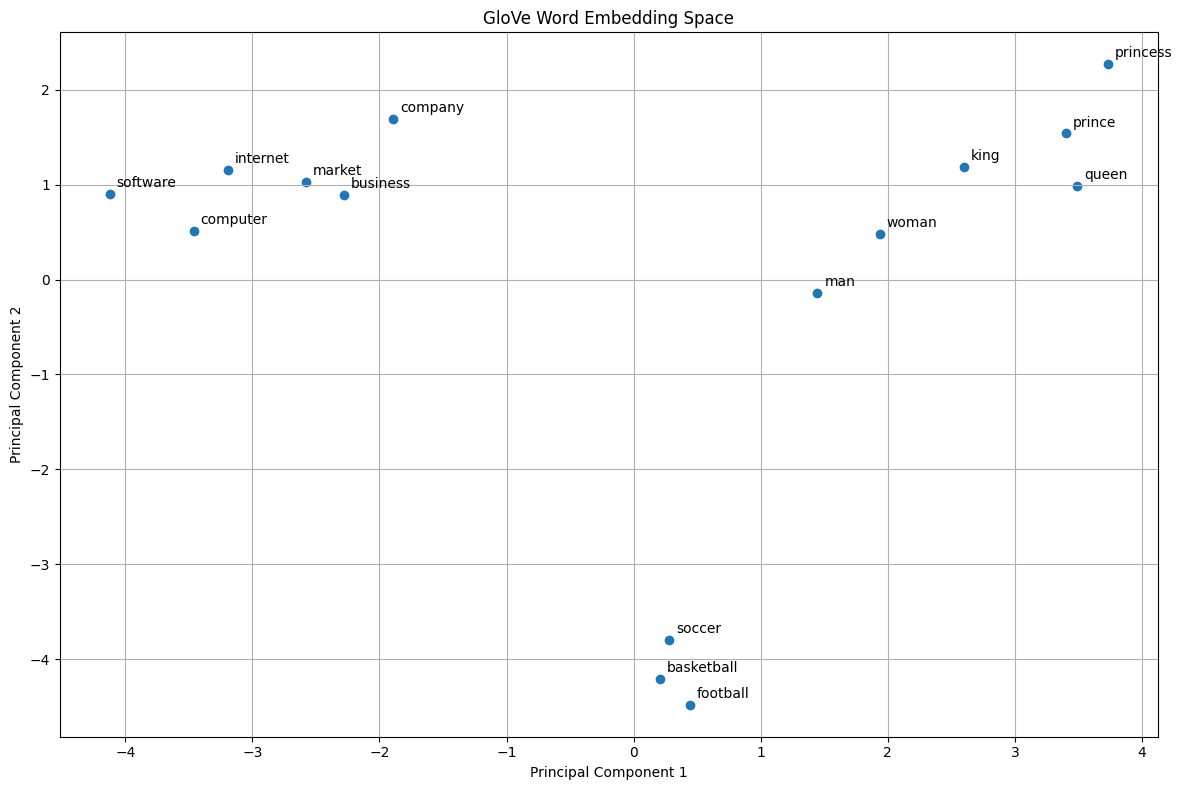

In [22]:
#Plot word embedding space
plt.figure(figsize=(12, 8))

plt.scatter(
    visual_2d[:, 0],
    visual_2d[:, 1]
)

for i, word in enumerate(visual_words):
    plt.annotate(
        word,
        (
            visual_2d[i, 0],
            visual_2d[i, 1]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GloVe Word Embedding Space")
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
#save artifacts
phase4_metadata = {
    "embedding_dimension": int(embedding_matrix.shape[1]),
    "vocabulary_size": len(words_list),
    "document_count": len(train_df),
    "search_representation": "Mean GloVe"
}

with open(
    "../artifacts/phase4_metadata.pkl",
    "wb"
) as f:
    pickle.dump(
        phase4_metadata,
        f
    )

print("Phase 4 metadata saved.")

Phase 4 metadata saved.


# Phase 5 — Streamlit Semantic Intelligence Application

## 1. Objective

The objective of Phase 5 was to transform the word-embedding experiments and machine-learning pipeline developed in Phases 1–4 into a complete interactive NLP application.

Rather than building a basic demonstration, the final application was designed as a small semantic intelligence system that exposes the main capabilities developed throughout the project:

- semantic news retrieval
- news topic classification
- word-vector exploration
- word similarity analysis
- word analogy solving
- embedding-space visualization
- dataset and model inspection

The application was implemented using Streamlit.

---

# 2. Final System

The final system combines pretrained GloVe word embeddings with document-level representations and a linear classification model.

The overall pipeline is:

```text
                         GloVe
                           │
                           ▼
                  50D Word Vectors
                           │
              ┌────────────┴────────────┐
              │                         │
              ▼                         ▼
        Word Operations          Document Embeddings
              │                         │
       ┌──────┼──────┐                  │
       │      │      │                  │
       ▼      ▼      ▼                  ▼
    Nearest  Analogies  PCA       Semantic Search
    Words                          │
                                  │
                                  ▼
                            Cosine Similarity
                                  │
                                  ▼
                         Related News Articles

Document Embedding
        │
        ▼
   Linear SVM
        │
        ▼
 World / Sports / Business / Sci/Tech